# Segmentation Evaluation & Morphometric Feature Extraction on `acme_ai` Dataset

This notebook performs a complete evaluation of three YOLO instance segmentation models:
1. **YOLOv8n-seg** (Nano)
2. **YOLOv8l-seg** (Large)
3. **YOLO11m-seg** (Medium)

We evaluate them on **Side** (lateral) and **Back** (rear/top) views of the **acme_ai** dataset. The notebook executes the following pipeline:
- Generates and saves binary masks (same dimensions as raw images) to `tests/segmentation_result/[model_name]/`.
- Computes IoU, Dice, Precision, and Recall statistics on all matched records.
- Displays inline visualizations comparing the predicted boundaries against the ground truth green masks.
- Performs morphometric feature extraction (Body Length, Withers Height, Chest Girth).
- Saves visualization plots to `tests/feature_extraction_result/[model_name]/`.
- Saves the numeric results in a single combined CSV file at `tests/feature_extraction_result/features.csv`.

In [1]:
import sys
import os
# Add parent directory to sys.path to enable importing cattle_weight module
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import time
from datetime import datetime, timedelta
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# Set matplotlib backend for inline rendering
%matplotlib inline

print("Libraries imported successfully.")

c:\Users\bimyu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully.


In [2]:
# Define dataset paths and import configuration
from cattle_weight.config import (
    CSV_PATH, DATA_DIR, ROI_LATERAL_X, ROI_LATERAL_Y, FLOOR_Y_LATERAL,
    ROI_TOP_X, ROI_TOP_Y, CHEST_X_RATIO
)
from cattle_weight import load_measurements
from cattle_weight.pipeline import find_image_by_id

print("Config loaded. Data directory:", DATA_DIR)

BACK_IMG_DIR = os.path.join(DATA_DIR, "Back", "images")
BACK_ANN_DIR = os.path.join(DATA_DIR, "Back", "annotations")

SIDE_IMG_DIR = os.path.join(DATA_DIR, "Side", "images")
SIDE_ANN_DIR = os.path.join(DATA_DIR, "Side", "annotations")

def load_gt_mask(ann_path):
    ann = cv2.imread(ann_path)
    if ann is None:
        return None
    # Green pixels: B=0, G=255, R=0
    mask = (ann[:, :, 0] == 0) & (ann[:, :, 1] == 255) & (ann[:, :, 2] == 0)
    return mask.astype(np.uint8) * 255

def compute_metrics(pred_mask, gt_mask):
    p = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)
    
    intersection = np.logical_and(p, gt).sum()
    union = np.logical_or(p, gt).sum()
    p_sum = p.sum()
    gt_sum = gt.sum()
    
    if union == 0:
        iou = 1.0
        dice = 1.0
        precision = 1.0
        recall = 1.0
    else:
        iou = float(intersection) / float(union)
        dice = (2.0 * intersection) / (p_sum + gt_sum) if (p_sum + gt_sum) > 0 else 0.0
        precision = float(intersection) / p_sum if p_sum > 0 else 0.0
        recall = float(intersection) / gt_sum if gt_sum > 0 else 0.0
        
    return {
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall
    }

Config loaded. Data directory: c:\Users\bimyu\Documents\Projects\Oneject\playground\datasets\acme_ai\Pixel_B2\B2


In [3]:
# Align and scan matched cattle IDs
matched_data = []
for idx in range(1, 600):
    side_img = find_image_by_id(SIDE_IMG_DIR, idx, 's')
    back_img = find_image_by_id(BACK_IMG_DIR, idx, 'r')
    
    if side_img and back_img:
        side_ann = os.path.join(SIDE_ANN_DIR, os.path.basename(side_img) + "___fuse.png")
        back_ann = os.path.join(BACK_ANN_DIR, os.path.basename(back_img) + "___fuse.png")
        
        if os.path.exists(side_ann) and os.path.exists(back_ann):
            # Extract manual weight in kg from the filename (the 3rd segment split by '_')
            parts = os.path.basename(side_img).split('_')
            weight_kg = float(parts[2]) if len(parts) >= 3 else 0.0
            
            matched_data.append({
                'id': idx,
                'side_img': side_img,
                'side_ann': side_ann,
                'back_img': back_img,
                'back_ann': back_ann,
                'weight_kg': weight_kg
            })

print(f"Found {len(matched_data)} matched cattle records with complete images and annotations.")

Found 509 matched cattle records with complete images and annotations.


In [4]:
# Create Output Directories
BASE_OUTPUT_DIR = os.path.join(os.path.dirname(os.path.dirname(DATA_DIR)), "tests")
SEG_RESULT_DIR = os.path.join(BASE_OUTPUT_DIR, "segmentation_result")
FEAT_RESULT_DIR = os.path.join(BASE_OUTPUT_DIR, "feature_extraction_result")

models_list = ['yolov8l']
for m in models_list:
    os.makedirs(os.path.join(SEG_RESULT_DIR, m), exist_ok=True)
    os.makedirs(os.path.join(FEAT_RESULT_DIR, m), exist_ok=True)

print("Output subfolders generated under tests/:")
print(f"  - {SEG_RESULT_DIR}")
print(f"  - {FEAT_RESULT_DIR}")

Output subfolders generated under tests/:
  - c:\Users\bimyu\Documents\Projects\Oneject\playground\datasets\acme_ai\tests\segmentation_result
  - c:\Users\bimyu\Documents\Projects\Oneject\playground\datasets\acme_ai\tests\feature_extraction_result


In [5]:
# Load YOLO Models
print("Loading models...")
model_v8n = YOLO("models/yolov8n-seg.pt")
model_v8l = YOLO("models/yolov8l-seg.pt")
model_v11m = YOLO("models/yolo11m-seg.pt")
print("Models loaded successfully.")

Loading models...
Models loaded successfully.


In [6]:
models = {
    'yolov8l': model_v8l
}

# ── Load trained sticker YOLO model ───────────────────────────────────────────
yolo_sticker_path = os.path.join(os.getcwd(), 'models', 'best_sticker.pt')
sticker_model = None
if os.path.exists(yolo_sticker_path):
    sticker_model = YOLO(yolo_sticker_path)
    print(f'Trained sticker YOLO model loaded: {yolo_sticker_path}')
else:
    print('WARNING: Trained sticker YOLO model not found. Will use HSV fallback.')


# ── Sticker detection using YOLO ──────────────────────────────────────────────
def detect_sticker_yolo(img):
    """
    Detect sticker using the fine-tuned YOLO segmentation model.
    Returns:
        binary_mask  (H x W uint8)  : Smooth polygon-filled binary mask at full resolution.
        polygon_pts  (N x 2 int32)  : Raw polygon vertices in image pixel coordinates.
    Both are None if no sticker detected.
    """
    if not sticker_model:
        return None, None
    results = sticker_model(img, retina_masks=True, verbose=False)[0]
    if results.masks is None or len(results.boxes) == 0:
        return None, None

    best_idx = int(np.argmax(results.boxes.conf.cpu().numpy()))

    # Get polygon coordinates at FULL image resolution (no pixelation)
    # results.masks.xy[i] is a (N, 2) float32 array in original image coordinates
    polygon_pts = results.masks.xy[best_idx].astype(np.int32)

    # Draw smooth filled polygon on a full-resolution blank canvas
    binary_mask = np.zeros(img.shape[:2], np.uint8)
    if len(polygon_pts) >= 3:
        cv2.fillPoly(binary_mask, [polygon_pts], 255)

    return binary_mask, polygon_pts


# ── Sticker detection using HSV color ─────────────────────────────────────────
def detect_sticker_hsv(img, cow_mask):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    color_targets = [
        {'lower': np.array([25, 20, 80]),  'upper': np.array([75, 255, 255])},   # Yellow-green
        {'lower': np.array([0,  0,  180]), 'upper': np.array([180, 45, 255])},   # Bright white
        {'lower': np.array([15, 30, 80]),  'upper': np.array([28, 255, 255])},   # Warm yellow
        {'lower': np.array([30, 30, 30]),  'upper': np.array([75, 255, 180])},   # Shadowed green
    ]

    broad = np.zeros(img.shape[:2], np.uint8)
    for t in color_targets:
        broad = cv2.bitwise_or(broad, cv2.inRange(hsv, t['lower'], t['upper']))

    cands = cv2.bitwise_and(broad, cow_mask)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cands = cv2.morphologyEx(cands, cv2.MORPH_CLOSE, k)
    cands = cv2.morphologyEx(cands, cv2.MORPH_OPEN, k)

    contours, _ = cv2.findContours(cands, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (200 <= area <= 10000):
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        ar = w / h
        ext = area / (w * h)
        if 0.6 <= ar <= 1.6 and ext >= 0.45:
            valid.append((abs(1.0 - ar) + abs(0.9 - ext), cnt))

    if not valid:
        return None, None
    valid.sort(key=lambda x: x[0])
    best_cnt = valid[0][1]

    mask = np.zeros(img.shape[:2], np.uint8)
    cv2.drawContours(mask, [best_cnt], -1, 255, -1)
    polygon_pts = best_cnt.reshape(-1, 2)
    return mask, polygon_pts


# ── Unified sticker detector (YOLO first, HSV fallback) ────────────────────────
def segment_sticker(img, cow_mask):
    mask, poly = None, None
    if sticker_model is not None:
        mask, poly = detect_sticker_yolo(img)
    if mask is None:
        mask, poly = detect_sticker_hsv(img, cow_mask)
    if mask is None:
        mask = np.zeros(img.shape[:2], np.uint8)
        poly = np.array([], dtype=np.int32)
    return mask, poly


# ── Side length estimators ─────────────────────────────────────────────────────
def sticker_side_from_binary(mask):
    """Estimate sticker side length (px) from binary mask area.
    Assumes a square sticker: side = sqrt(pixel_area).
    Does NOT account for tilt/perspective distortion.
    """
    area = float(np.count_nonzero(mask))
    return np.sqrt(area) if area > 0 else 0.0


def sticker_side_from_polygon(polygon_pts):
    """Estimate sticker side length (px) from polygon using min-area rotated rectangle.
    Works correctly even when the sticker is tilted / pitched.
    Returns (side_px, angle_deg, rect) where rect = cv2.minAreaRect output.
    """
    if polygon_pts is None or len(polygon_pts) < 3:
        return 0.0, 0.0, None
    rect = cv2.minAreaRect(polygon_pts)          # ((cx, cy), (w, h), angle)
    w, h = rect[1]
    angle = rect[2]
    # For a (nearly) square sticker the two sides should be equal;
    # take the geometric mean to be robust to slight non-squareness
    side_px = np.sqrt(w * h) if (w > 0 and h > 0) else 0.0
    return side_px, angle, rect


# ── Cow segmentation helper ────────────────────────────────────────────────────
def get_prediction_mask(model, img):
    results = model(img, retina_masks=True, verbose=False)[0]
    if results.masks is None or len(results.boxes) == 0:
        return np.zeros(img.shape[:2], dtype=np.uint8)
    best_idx = int(np.argmax(results.boxes.conf.cpu().numpy()))
    # Use polygon path for smooth cow mask too
    polygon_pts = results.masks.xy[best_idx].astype(np.int32)
    mask = np.zeros(img.shape[:2], np.uint8)
    if len(polygon_pts) >= 3:
        cv2.fillPoly(mask, [polygon_pts], 255)
    return mask


# ── Main extraction loop ───────────────────────────────────────────────────────
results_metrics = []
sticker_comparison = []   # Binary-method vs Polygon-method side lengths

start_time_all = time.time()
print(f'Processing full segmentation mask extraction for {len(matched_data)} records...')

for count, sample in enumerate(matched_data):
    cow_id = sample['id']
    current_time_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    if count >= 1:
        elapsed = time.time() - start_time_all
        avg_t = elapsed / count
        eta = datetime.now() + timedelta(seconds=avg_t * (len(matched_data) - count))
        print(f'[{current_time_str}] Cow {cow_id} ({count+1}/{len(matched_data)}) | Elapsed: {elapsed:.1f}s | ETA: {eta.strftime("%H:%M:%S")}')
    else:
        print(f'[{current_time_str}] Cow {cow_id} (1/{len(matched_data)})')

    side_frame = cv2.imread(sample['side_img'])
    back_frame = cv2.imread(sample['back_img'])
    side_gt   = load_gt_mask(sample['side_ann'])
    back_gt   = load_gt_mask(sample['back_ann'])

    first_model = True
    for name, model in models.items():
        # ── Cow masks (smooth polygon) ──────────────────────────────
        side_pred = get_prediction_mask(model, side_frame)
        back_pred = get_prediction_mask(model, back_frame)

        side_metrics = compute_metrics(side_pred, side_gt)
        back_metrics = compute_metrics(back_pred, back_gt)

        # ── Sticker detection (first model pass only to save time) ──
        sticker_mask, sticker_poly = segment_sticker(side_frame, side_pred)

        # --- Method A: binary-area side length
        side_binary = sticker_side_from_binary(sticker_mask)

        # --- Method B: polygon minAreaRect side length
        poly_pts = sticker_poly if (sticker_poly is not None and len(sticker_poly) >= 3) else None
        side_poly, angle_deg, rot_rect = sticker_side_from_polygon(poly_pts)

        if first_model:
            sticker_comparison.append({
                'id'             : cow_id,
                'side_binary_px' : round(side_binary, 2),
                'side_polygon_px': round(side_poly,   2),
                'tilt_deg'       : round(angle_deg,   2),
                'poly_pts_count' : len(sticker_poly) if sticker_poly is not None else 0,
            })
            first_model = False

        # ── Build color overlay mask for side view ──────────────────
        color_side = np.zeros((*side_frame.shape[:2], 3), dtype=np.uint8)
        color_side[side_pred == 255] = [0, 255, 0]       # Cow → green
        color_side[sticker_mask == 255] = [0, 255, 255]  # Sticker binary → yellow

        # Draw sticker polygon boundary as a visible line
        if sticker_poly is not None and len(sticker_poly) >= 3:
            cv2.polylines(color_side, [sticker_poly], isClosed=True,
                          color=(0, 0, 255), thickness=3)   # Red outline

        # Draw rotated rect (min area) in blue dashes for size comparison
        if rot_rect is not None:
            box_pts = cv2.boxPoints(rot_rect).astype(np.int32)
            cv2.drawContours(color_side, [box_pts], 0, (255, 0, 0), 2)  # Blue rect

        # ── Build color overlay mask for back view ──────────────────
        color_back = np.zeros((*back_frame.shape[:2], 3), dtype=np.uint8)
        color_back[back_pred == 255] = [0, 255, 0]          # Cow → green

        # ── Save masks ──────────────────────────────────────────────
        side_mask_name = os.path.splitext(os.path.basename(sample['side_img']))[0] + '.png'
        back_mask_name = os.path.splitext(os.path.basename(sample['back_img']))[0] + '.png'
        cv2.imwrite(os.path.join(SEG_RESULT_DIR, name, side_mask_name), color_side)
        cv2.imwrite(os.path.join(SEG_RESULT_DIR, name, back_mask_name), color_back)

        results_metrics.append({'id': cow_id, 'model': name, 'view': 'Side', **side_metrics})
        results_metrics.append({'id': cow_id, 'model': name, 'view': 'Back', **back_metrics})

df_results = pd.DataFrame(results_metrics)
df_sticker = pd.DataFrame(sticker_comparison)

print('Segmentation masks successfully extracted and saved.')
print(f'Sticker comparison (first 5 rows):')
print(df_sticker.head())


Trained sticker YOLO model loaded: c:\Users\bimyu\Documents\Projects\Oneject\playground\runs\segment\train_sticker\weights\best.pt
Processing full segmentation mask extraction for 509 records...
[2026-07-02 11:11:18] Cow 1 (1/509)
[2026-07-02 11:11:22] Cow 2 (2/509) | Elapsed: 4.0s | ETA: 11:44:57
[2026-07-02 11:11:25] Cow 3 (3/509) | Elapsed: 7.1s | ETA: 11:41:15
[2026-07-02 11:11:29] Cow 4 (4/509) | Elapsed: 10.8s | ETA: 11:41:48
[2026-07-02 11:11:32] Cow 5 (5/509) | Elapsed: 14.1s | ETA: 11:41:11
[2026-07-02 11:11:35] Cow 6 (6/509) | Elapsed: 17.0s | ETA: 11:40:12
[2026-07-02 11:11:38] Cow 7 (7/509) | Elapsed: 20.0s | ETA: 11:39:35
[2026-07-02 11:11:41] Cow 8 (8/509) | Elapsed: 22.9s | ETA: 11:39:04
[2026-07-02 11:11:45] Cow 9 (9/509) | Elapsed: 26.8s | ETA: 11:39:42
[2026-07-02 11:11:48] Cow 10 (10/509) | Elapsed: 29.9s | ETA: 11:39:30
[2026-07-02 11:11:51] Cow 11 (11/509) | Elapsed: 33.0s | ETA: 11:39:19
[2026-07-02 11:11:55] Cow 12 (12/509) | Elapsed: 36.6s | ETA: 11:39:33
[2026-

In [7]:
# Display statistical tables
summary = df_results.groupby(['view', 'model'])[['iou', 'dice', 'precision', 'recall']].mean().reset_index()
summary_std = df_results.groupby(['view', 'model'])[['iou', 'dice', 'precision', 'recall']].std().reset_index()

print("=== MEAN PERFORMANCE METRICS OVER ALL COWS ===")
display(summary.round(4))

print("\n=== STANDARD DEVIATION OF METRICS OVER ALL COWS ===")
display(summary_std.round(4))

=== MEAN PERFORMANCE METRICS OVER ALL COWS ===


,view,model,iou,dice,precision,recall
0,Back,yolov8l,0.9086,0.9448,0.9158,0.9760
1,Side,yolov8l,0.9295,0.9634,0.9348,0.9941



=== STANDARD DEVIATION OF METRICS OVER ALL COWS ===


,view,model,iou,dice,precision,recall
0,Back,yolov8l,0.1166,0.120,0.1170,0.1241
1,Side,yolov8l,0.0128,0.007,0.0132,0.0045



==================== VISUALIZATION FOR SIDE VIEW ====================


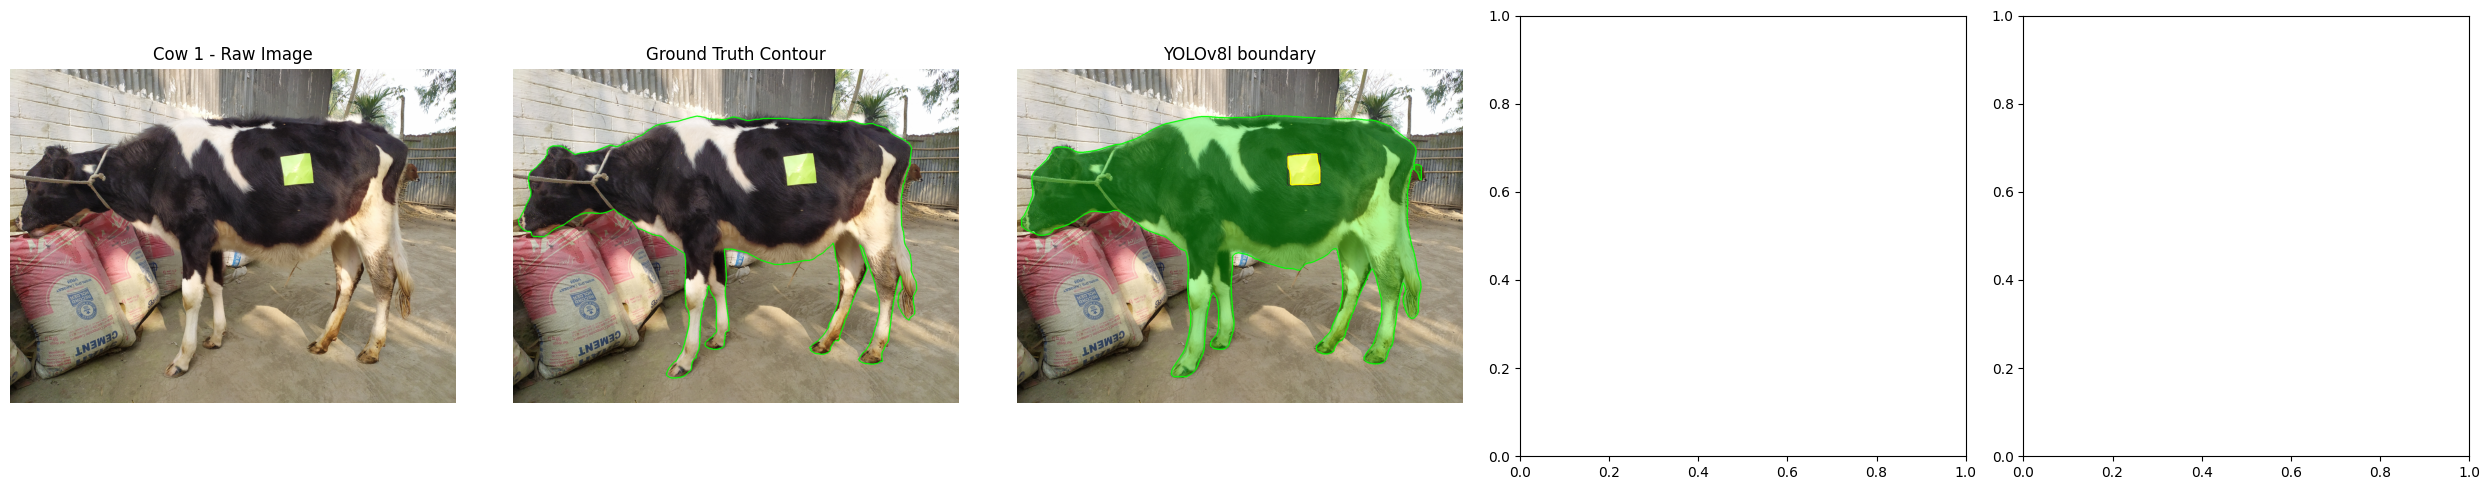

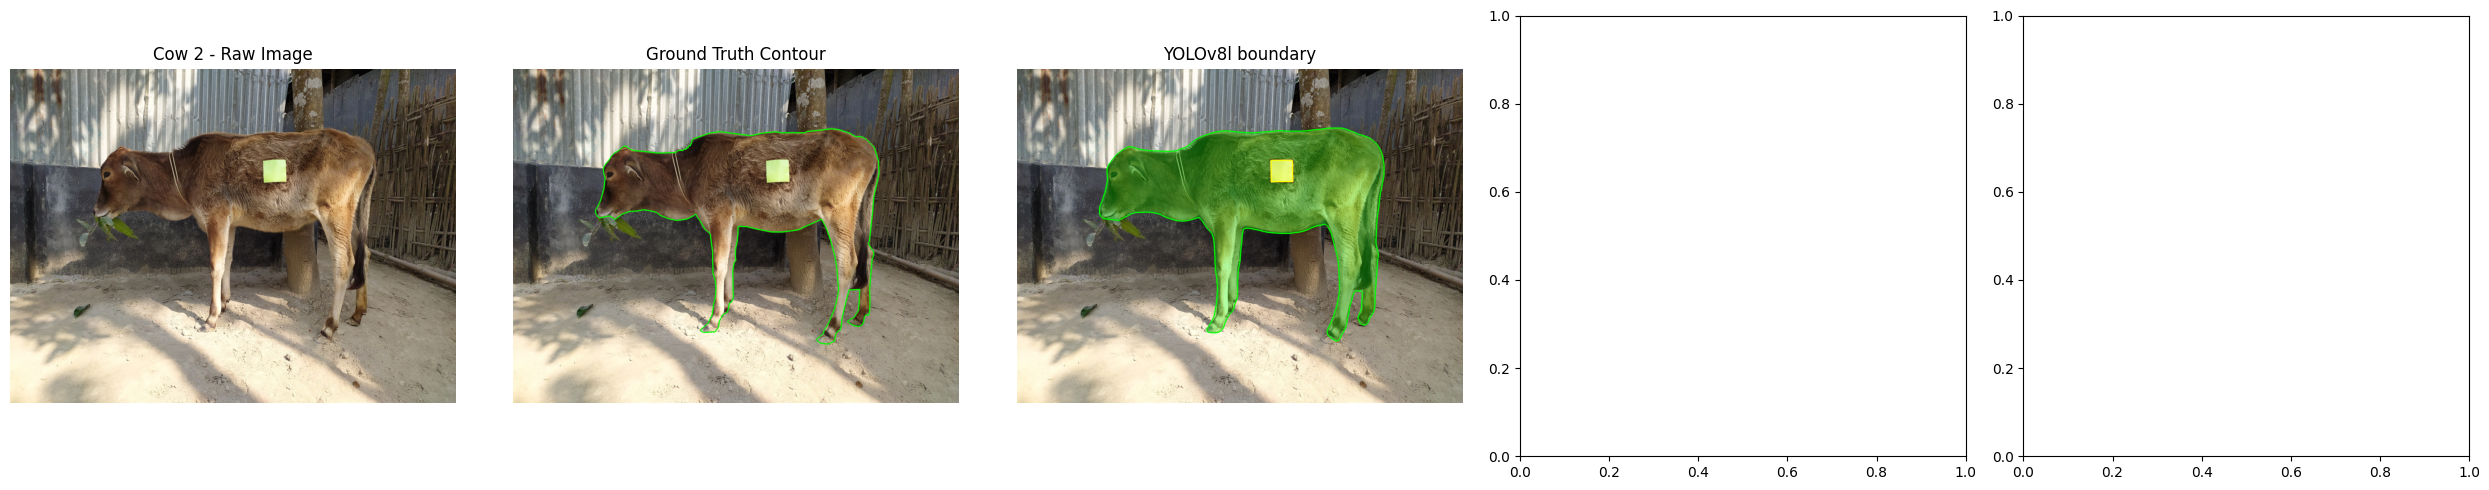

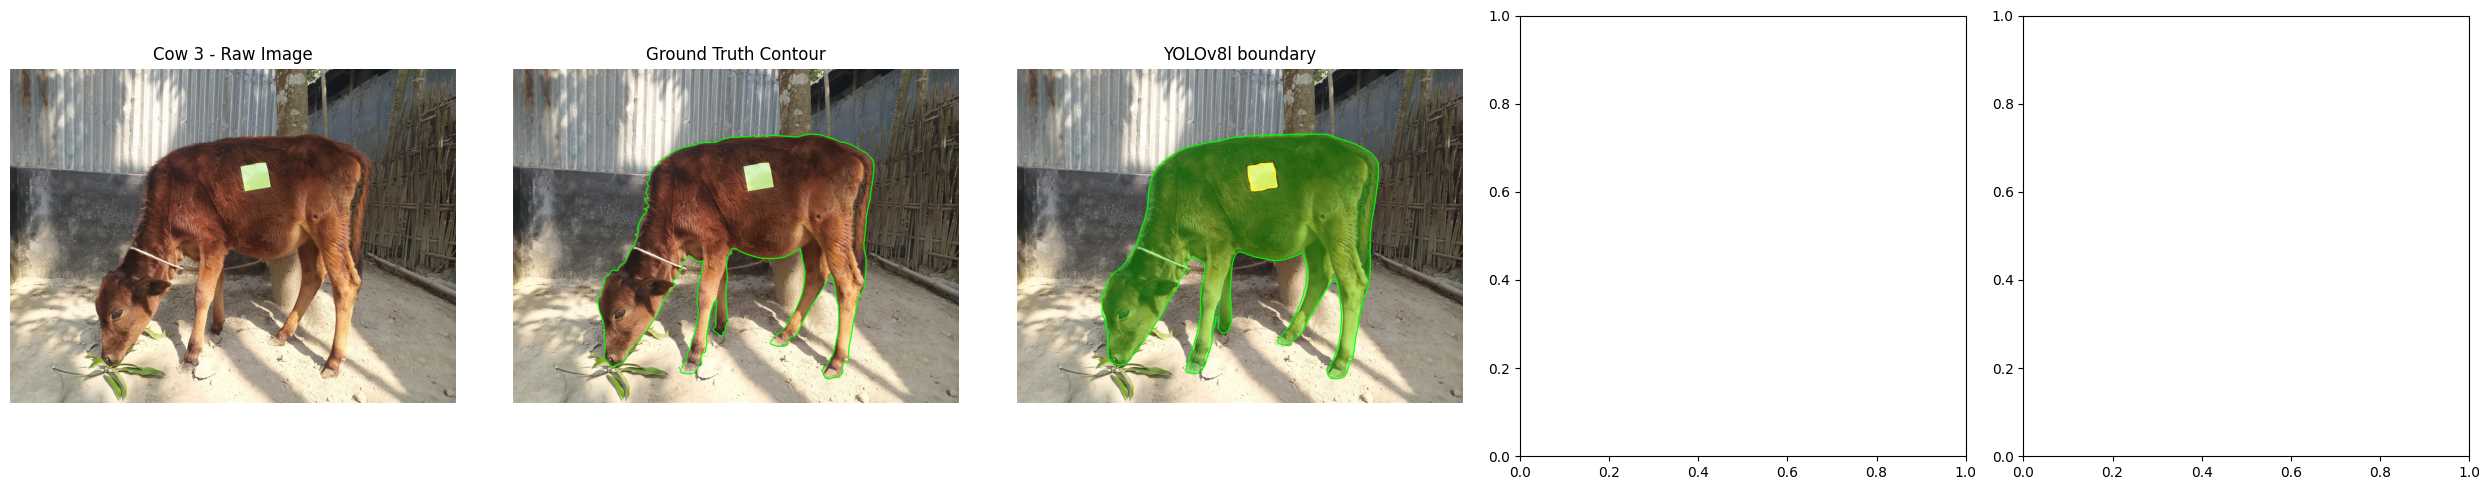

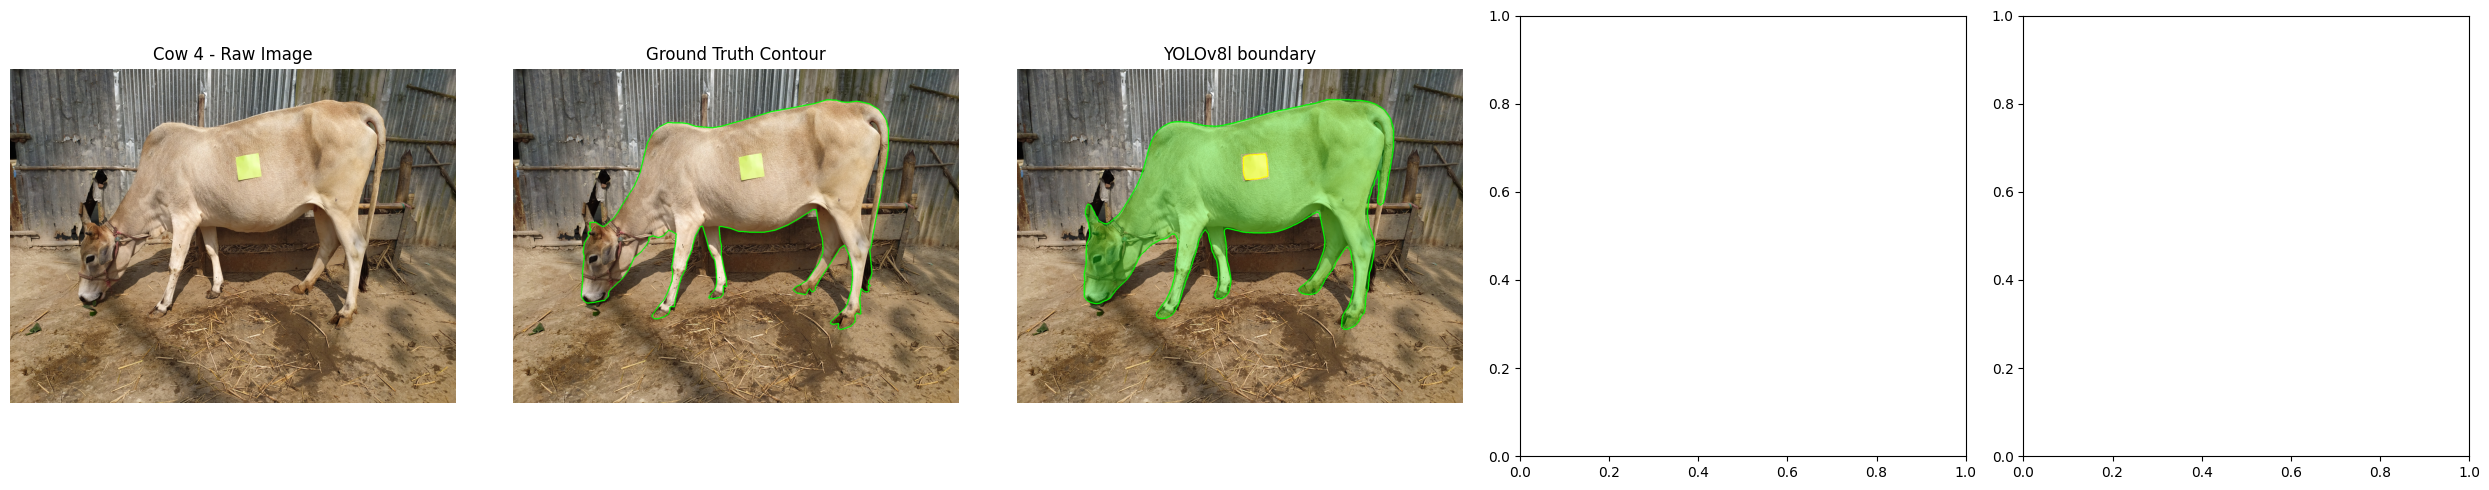

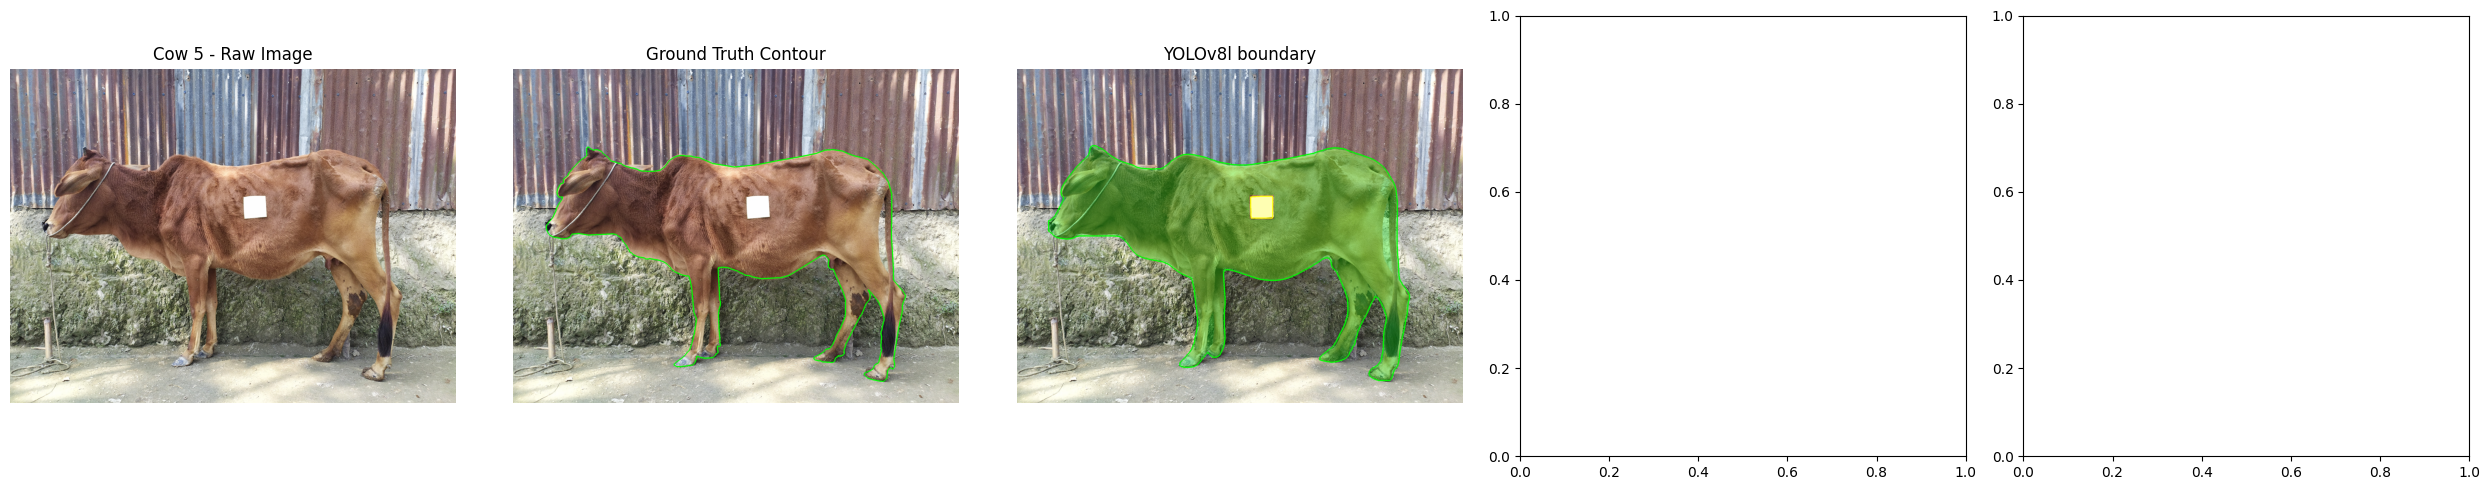


==================== VISUALIZATION FOR BACK VIEW ====================


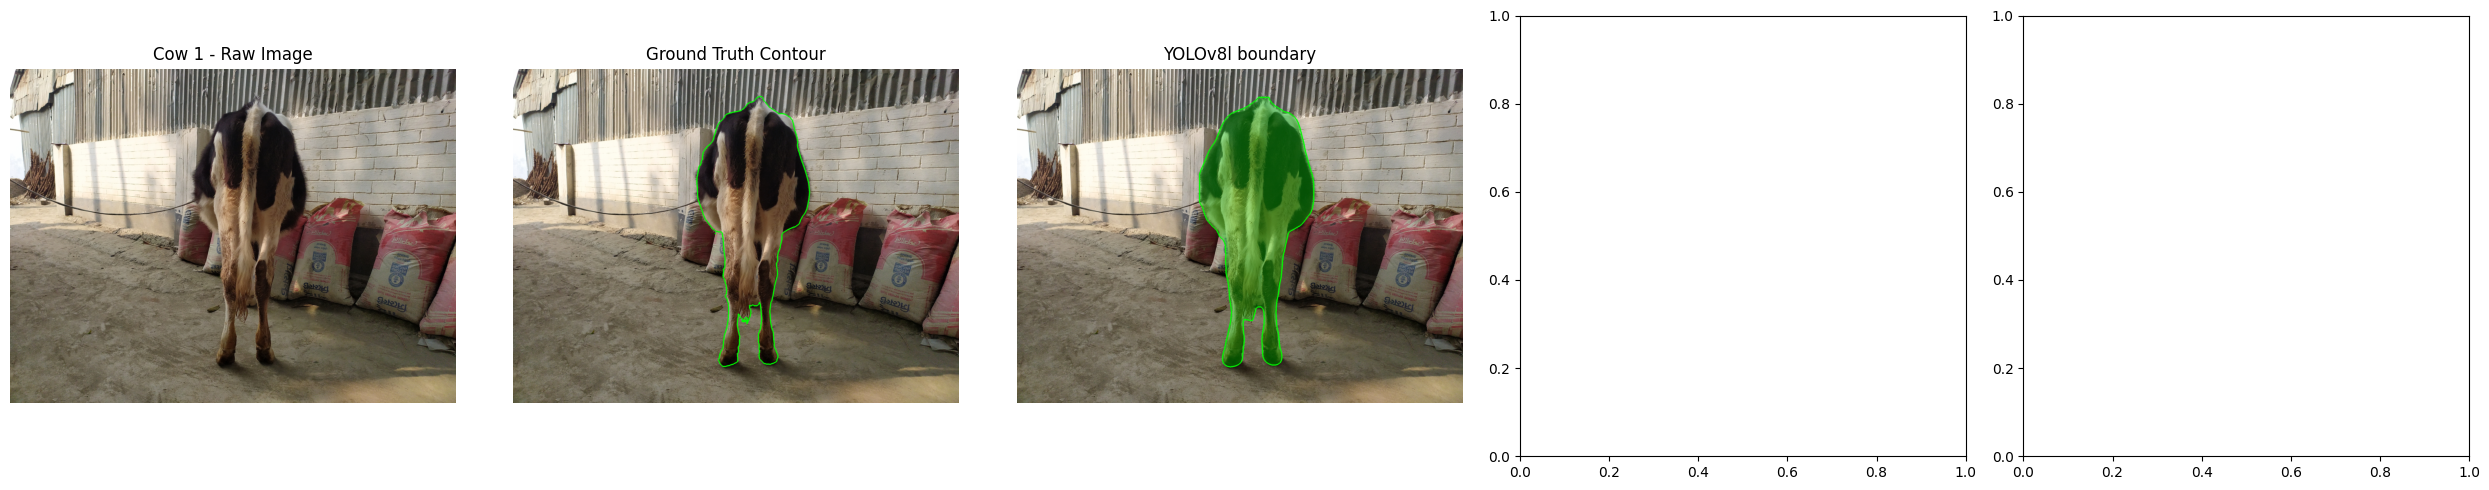

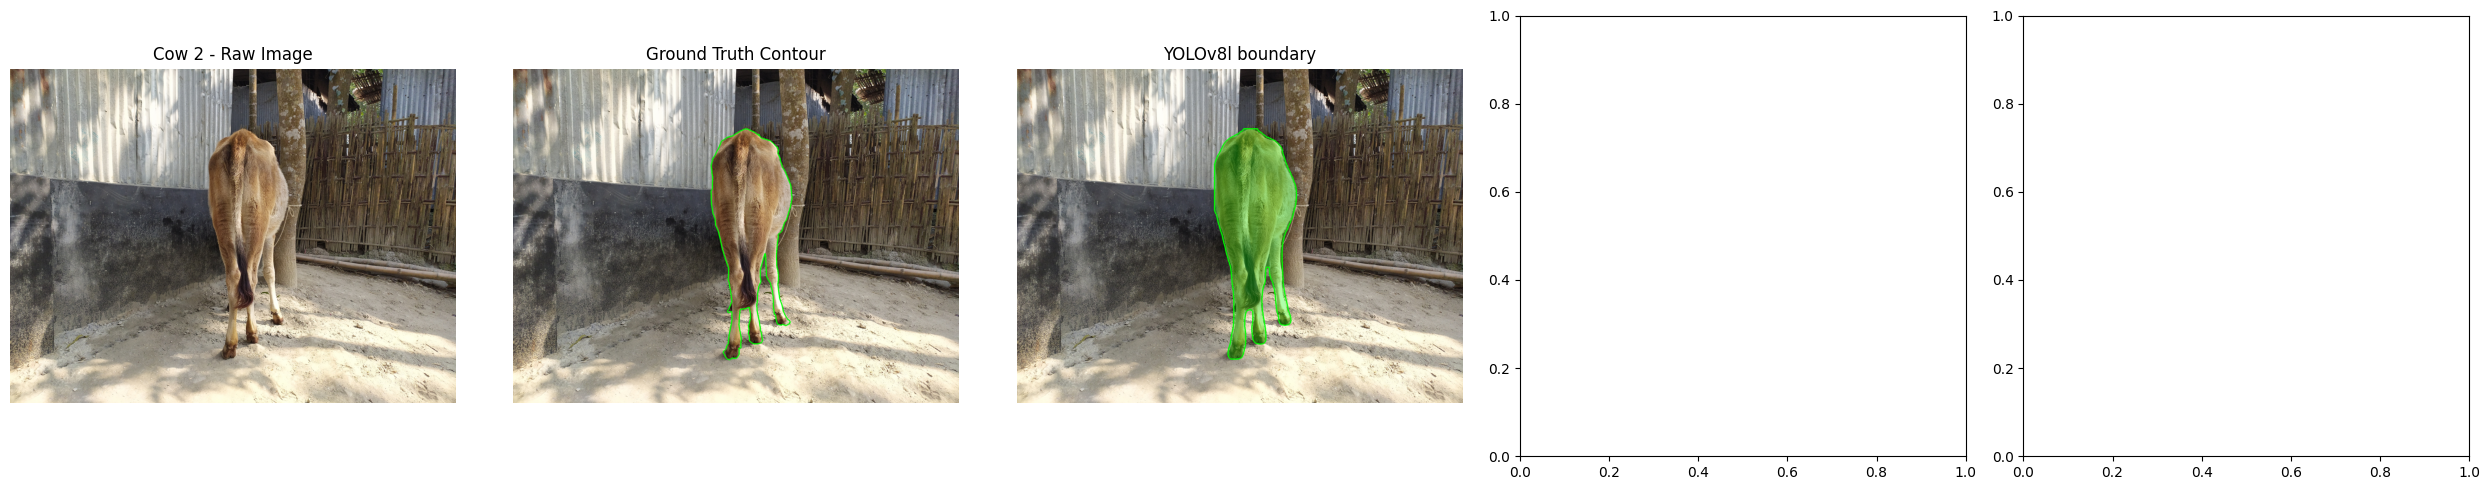

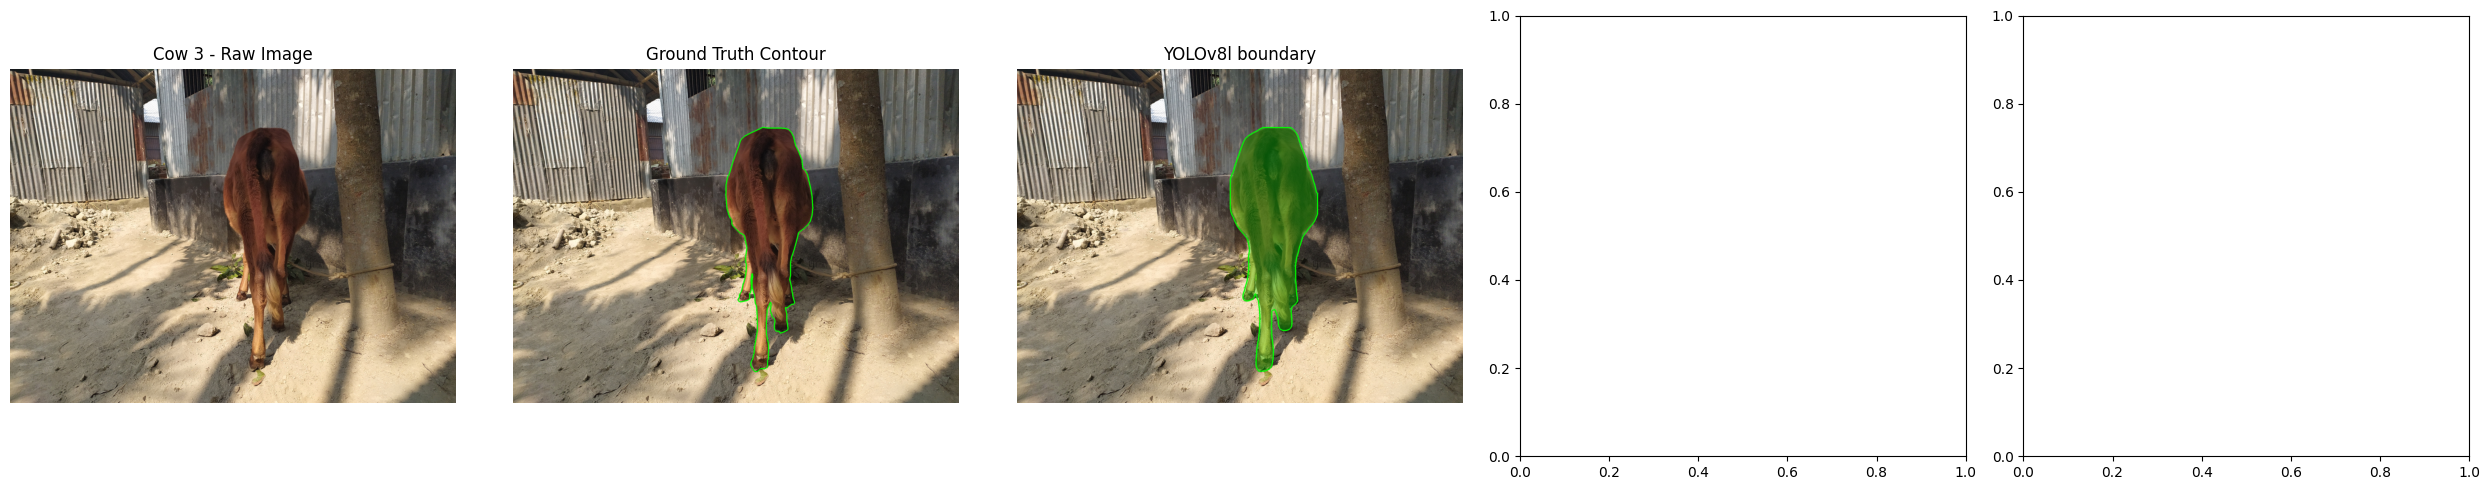

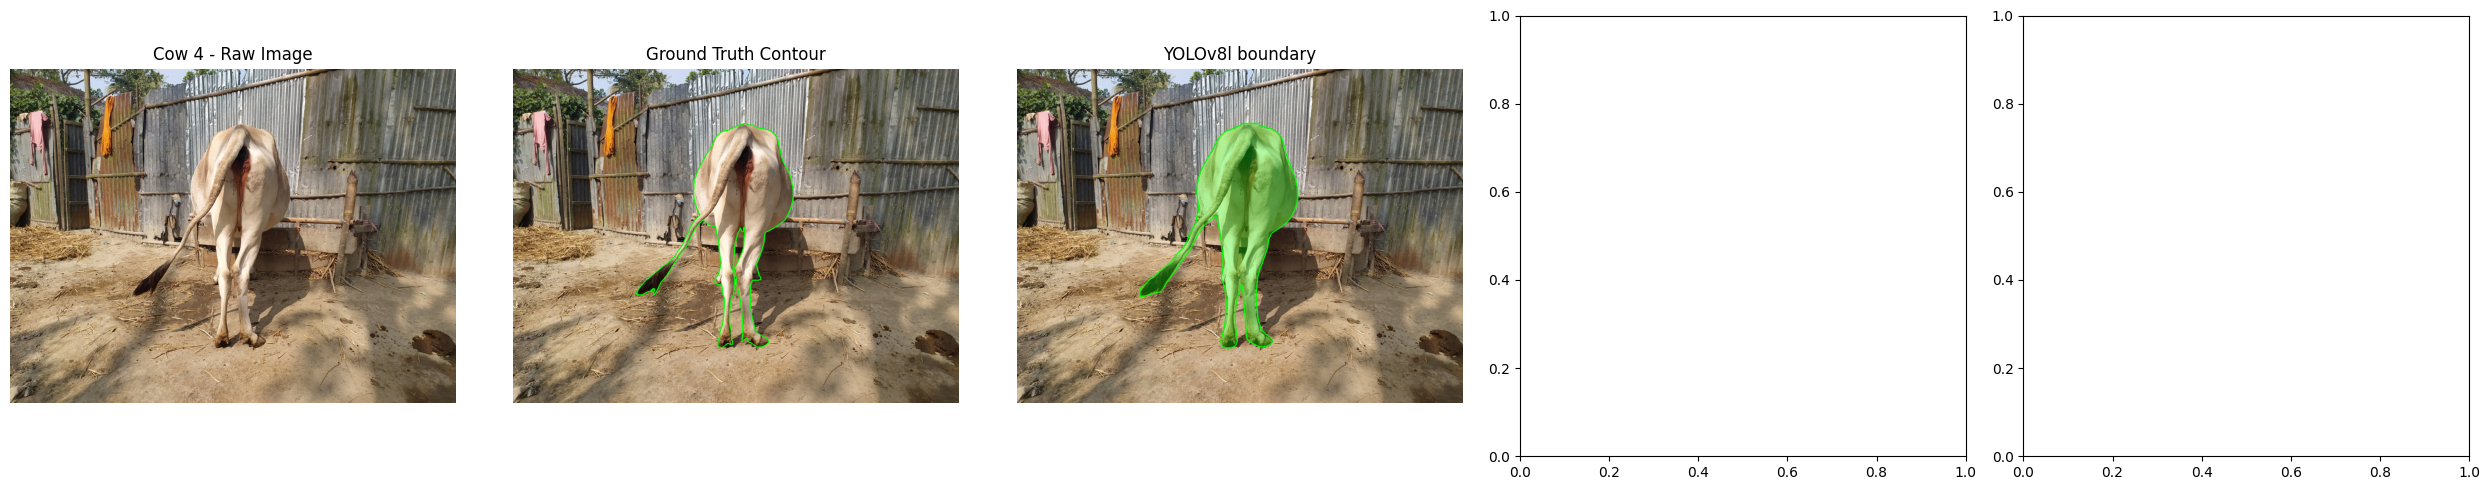

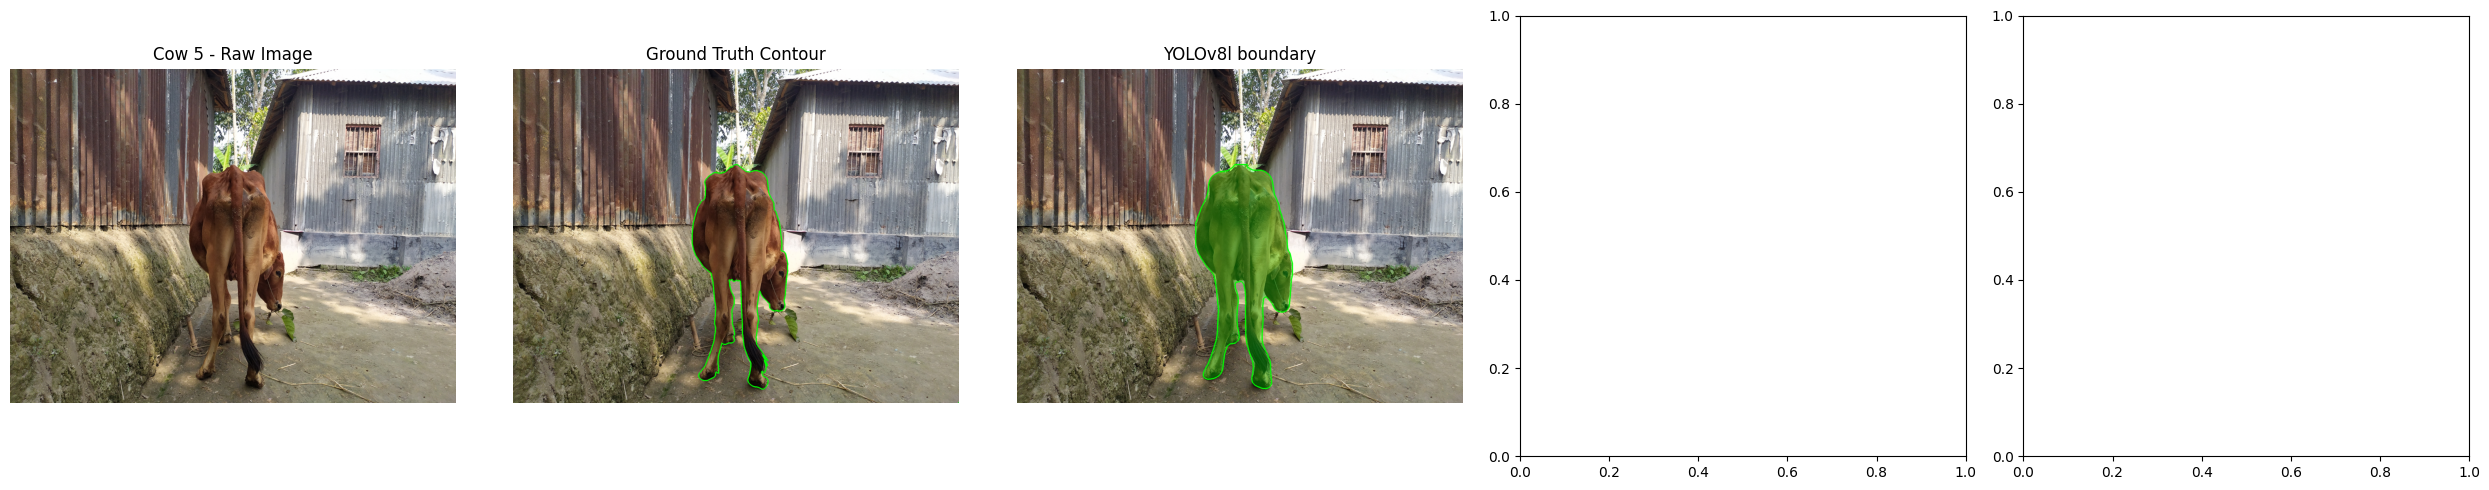

In [8]:
# Render and display visual segmentations (10 subplots)
viz_samples = matched_data[:5]

def draw_boundary(img, mask, color=(0, 255, 0), thickness=3):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    canvas = img.copy()
    cv2.drawContours(canvas, contours, -1, color, thickness)
    return canvas

def draw_colored_predictions(img_rgb, mask_bgr):
    # mask_bgr has cow in green [0, 255, 0], sticker in yellow [0, 255, 255]
    # In RGB: green is [0, 255, 0], yellow is [255, 255, 0]
    if mask_bgr is None:
        return img_rgb.copy()
    
    cow_mask = ((mask_bgr[:, :, 1] == 255) & (mask_bgr[:, :, 2] == 0)).astype(np.uint8) * 255
    sticker_mask = ((mask_bgr[:, :, 1] == 255) & (mask_bgr[:, :, 2] == 255)).astype(np.uint8) * 255
    
    canvas = img_rgb.copy()
    
    # Semi-transparent overlay
    overlay = canvas.copy()
    overlay[cow_mask == 255] = [0, 255, 0]
    overlay[sticker_mask == 255] = [255, 255, 0]
    canvas = cv2.addWeighted(canvas, 0.7, overlay, 0.3, 0)
    
    # Draw boundaries
    contours_cow, _ = cv2.findContours(cow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(canvas, contours_cow, -1, (0, 255, 0), 4)
    
    contours_sticker, _ = cv2.findContours(sticker_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(canvas, contours_sticker, -1, (255, 255, 0), 4)
    
    return canvas

for view in ['Side', 'Back']:
    print(f"\n==================== VISUALIZATION FOR {view.upper()} VIEW ====================")
    for sample in viz_samples:
        cow_id = sample['id']
        img_path = sample['side_img'] if view == 'Side' else sample['back_img']
        ann_path = sample['side_ann'] if view == 'Side' else sample['back_ann']
        
        raw_img = cv2.imread(img_path)
        raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        
        gt_mask = load_gt_mask(ann_path)
        gt_overlay = draw_boundary(raw_rgb, gt_mask, color=(0, 255, 0), thickness=4)
        
        
        pred_v8l_color = cv2.imread(os.path.join(SEG_RESULT_DIR, 'yolov8l', os.path.splitext(os.path.basename(img_path))[0] + ".png"))
        boundary_v8l = draw_colored_predictions(raw_rgb, pred_v8l_color)

        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        axes[0].imshow(raw_rgb)
        axes[0].set_title(f"Cow {cow_id} - Raw Image")
        axes[0].axis('off')
        
        axes[1].imshow(gt_overlay)
        axes[1].set_title("Ground Truth Contour")
        axes[1].axis('off')
        
        axes[2].imshow(boundary_v8l)
        axes[2].set_title("YOLOv8l boundary")
        axes[2].axis('off')
        
        
        plt.tight_layout()
        plt.show()

In [9]:
# ─── Morphometric Feature Extraction with On-The-Fly Sticker Calibration ───
import math
models_list = ['yolov8l']

# STICKER_REAL_SIDE_CM = 4.0 inches * 2.54 = 10.16 cm
STICKER_REAL_SIDE_CM = 10.16
FLOOR_Y_LATERAL = 1420
CHEST_X_RATIO = 0.30

def ramanujan_girth(a, b, correction=1.15):
    """Ramanujan ellipse circumference with correction factor."""
    if a <= 0 or b <= 0:
        return 0.0
    h = ((a - b) ** 2) / ((a + b) ** 2)
    return correction * np.pi * (a + b) * (1.0 + (3.0 * h) / (10.0 + np.sqrt(4.0 - 3.0 * h)))

# Fallback values if sticker is completely missed
avg_scale_lat_fallback = 0.06842
avg_scale_top_fallback = 0.07925

features_by_model = {m: {} for m in models_list}
scale_factors_side = {}
scale_factors_back = {}
sticker_tilts = {}

print(f"Running bulk morphometric feature extraction with dual calibration for all {len(matched_data)} cows...")
for count, sample in enumerate(matched_data):
    idx = sample['id']
    weight_kg = sample['weight_kg']
    
    if (count + 1) % 50 == 0:
        print(f"Processing cow {count + 1}/{len(matched_data)}...")
        
    lat_mask_name = os.path.splitext(os.path.basename(sample['side_img']))[0] + ".png"
    top_mask_name = os.path.splitext(os.path.basename(sample['back_img']))[0] + ".png"
    
    lat_frame = cv2.imread(sample['side_img'])
    top_frame = cv2.imread(sample['back_img'])
    if lat_frame is None or top_frame is None:
        continue
        
    # Load yolov8l predictions to use as the base for scale factor calculation
    lat_mask_color_l = cv2.imread(os.path.join(SEG_RESULT_DIR, 'yolov8l', lat_mask_name))
    lat_mask_l = (lat_mask_color_l[:, :, 1] == 255).astype(np.uint8) * 255 if lat_mask_color_l is not None else None
    top_mask_color_l = cv2.imread(os.path.join(SEG_RESULT_DIR, 'yolov8l', top_mask_name))
    top_mask_l = (top_mask_color_l[:, :, 1] == 255).astype(np.uint8) * 255 if top_mask_color_l is not None else None

    # 1. Detect sticker using high-resolution YOLO model on side view
    # (Falls back to HSV if YOLO model is not loaded)
    cow_mask_for_sticker = lat_mask_l if lat_mask_l is not None else np.zeros(lat_frame.shape[:2], np.uint8)
    sticker_mask, sticker_poly = segment_sticker(lat_frame, cow_mask_for_sticker)
    
    S_side = None
    tilt_deg = 0.0
    if sticker_mask is not None:
        side_poly_px, tilt_deg, _ = sticker_side_from_polygon(sticker_poly)
        if side_poly_px > 0:
            S_side = STICKER_REAL_SIDE_CM / side_poly_px
            
    # 2. Extract withers height pixels for side and back views
    # WH_side_px = FLOOR_Y_LATERAL - y_min_lat
    # WH_back_px = y_max_back - y_min_back
    WH_side_px = 0.0
    WH_back_px = 0.0
    if lat_mask_l is not None and top_mask_l is not None:
        white_y_lat_l = np.where(lat_mask_l == 255)[0]
        white_y_top_l = np.where(top_mask_l == 255)[0]
        if len(white_y_lat_l) > 0 and len(white_y_top_l) > 0:
            y_min_lat_l = white_y_lat_l.min()
            WH_side_px = float(FLOOR_Y_LATERAL - y_min_lat_l)
            WH_back_px = float(white_y_top_l.max() - white_y_top_l.min())
            
    # 3. Calculate scale factors
    if S_side is None:
        S_side = avg_scale_lat_fallback
        
    if WH_side_px > 0 and WH_back_px > 0:
        S_back = S_side * (WH_side_px / WH_back_px)
    else:
        S_back = avg_scale_top_fallback
        
    scale_factors_side[idx] = round(S_side, 6)
    scale_factors_back[idx] = round(S_back, 6)
    sticker_tilts[idx] = round(tilt_deg, 2)
    
    # 4. Run feature extraction for all three models
    for m_name in models_list:
        lat_mask_color = cv2.imread(os.path.join(SEG_RESULT_DIR, m_name, lat_mask_name))
        lat_mask = (lat_mask_color[:, :, 1] == 255).astype(np.uint8) * 255 if lat_mask_color is not None else None
        
        top_mask_color = cv2.imread(os.path.join(SEG_RESULT_DIR, m_name, top_mask_name))
        top_mask = (top_mask_color[:, :, 1] == 255).astype(np.uint8) * 255 if top_mask_color is not None else None
        
        if lat_mask is None or top_mask is None:
            continue
            
        try:
            # Extract coordinates and pixel width/height
            white_y_lat, white_x_lat = np.where(lat_mask == 255)
            y_min_lat = white_y_lat.min()
            x_min_lat, x_max_lat = white_x_lat.min(), white_x_lat.max()
            lat_w_px = float(x_max_lat - x_min_lat)
            
            white_y_top, white_x_top = np.where(top_mask == 255)
            y_min_top, y_max_top = white_y_top.min(), white_y_top.max()
            x_min_top, x_max_top = white_x_top.min(), white_x_top.max()
            top_w_px = float(x_max_top - x_min_top)
            
            # Chest Depth semi-axis b_px (from side view at 30% body length)
            # Clip to upper body (top 55% of mask height) to exclude leg pixels
            chest_x_lat = x_min_lat + CHEST_X_RATIO * lat_w_px
            body_cutoff_lat = int(y_min_lat + 0.55 * (FLOOR_Y_LATERAL - y_min_lat))
            col_full_lat = np.where(lat_mask[:, int(chest_x_lat)] == 255)[0]
            col_indices_lat = col_full_lat[col_full_lat <= body_cutoff_lat]
            if len(col_indices_lat) == 0:
                col_indices_lat = col_full_lat  # fallback
            b_px = float(col_indices_lat.max() - col_indices_lat.min()) / 2.0 if len(col_indices_lat) > 0 else 0.0
            
            # Chest Width semi-axis a_px (from back view at 25% from top = upper trunk)
            # Changed from 40% (thigh region) to 25% (shoulder/chest area)
            y_chest_top = y_min_top + 0.25 * (y_max_top - y_min_top)
            row_indices_top = np.where(top_mask[int(y_chest_top), :] == 255)[0]
            a_px = float(row_indices_top.max() - row_indices_top.min()) / 2.0 if len(row_indices_top) > 0 else top_w_px / 4.0
            
            # Convert to physical values (in cm)
            BL_lateral_cm = lat_w_px * S_side
            b_cm = b_px * S_side
            a_cm = a_px * S_back
            WH_cm = (FLOOR_Y_LATERAL - y_min_lat) * S_side
            
            # Calculate Girth
            CG_cm = ramanujan_girth(a_cm, b_cm)
            
            # Save morphometry features
            features_by_model[m_name][idx] = {
                'BL': round(BL_lateral_cm, 2),
                'WH': round(WH_cm, 2),
                'CG': round(CG_cm, 2)
            }
            
            # Generate visual overlays to verify the results
            # (We only save overlays to avoid notebook bloating)
            if (count + 1) % 50 == 0:
                lat_rgb = cv2.cvtColor(lat_frame, cv2.COLOR_BGR2RGB)
                top_rgb = cv2.cvtColor(top_frame, cv2.COLOR_BGR2RGB)
                y_start_lat = col_indices_lat.min() if len(col_indices_lat) > 0 else y_min_lat
                y_end_lat = col_indices_lat.max() if len(col_indices_lat) > 0 else FLOOR_Y_LATERAL
                y_start_top = np.where(top_mask[:, int(x_min_top + CHEST_X_RATIO*top_w_px)] == 255)[0].min() if len(np.where(top_mask[:, int(x_min_top + CHEST_X_RATIO*top_w_px)] == 255)[0]) > 0 else 0
                y_end_top = np.where(top_mask[:, int(x_min_top + CHEST_X_RATIO*top_w_px)] == 255)[0].max() if len(np.where(top_mask[:, int(x_min_top + CHEST_X_RATIO*top_w_px)] == 255)[0]) > 0 else top_frame.shape[0]
                
                fig, axes = plt.subplots(1, 3, figsize=(24, 7))
                axes[0].imshow(lat_rgb)
                axes[0].plot([x_min_lat + lat_w_px/2.0, x_min_lat + lat_w_px/2.0], [y_min_lat, FLOOR_Y_LATERAL], color='cyan', linewidth=4, label=f"WH = {WH_cm:.1f} cm")
                axes[0].plot([x_min_lat, x_max_lat], [y_min_lat + 200, y_min_lat + 200], color='yellow', linewidth=4, label=f"BL = {BL_lateral_cm:.1f} cm")
                axes[0].plot([chest_x_lat, chest_x_lat], [y_start_lat, y_end_lat], color='magenta', linewidth=4, label=f"Depth 2b = {2*b_cm:.1f} cm")
                axes[0].set_title(f"Cow {idx} (Side) - Scale factor: {S_side:.5f}")
                axes[0].legend(loc='upper right')
                axes[0].axis('off')
                
                axes[1].imshow(top_rgb)
                axes[1].plot([x_min_top, x_max_top], [top_frame.shape[0]/2.0, top_frame.shape[0]/2.0], color='yellow', linewidth=4, label=f"Rear Width")
                axes[1].plot([x_min_top + a_px, x_min_top + a_px], [y_start_top, y_end_top], color='magenta', linewidth=4, label=f"Width 2a = {2*a_cm:.1f} cm")
                axes[1].set_title(f"Cow {idx} (Back) - Scale factor: {S_back:.5f}")
                axes[1].legend(loc='upper right')
                axes[1].axis('off')
                
                ellipse = patches.Ellipse((0, 0), width=2*a_cm, height=2*b_cm, angle=0.0, fill=True, color='lightblue', alpha=0.6, edgecolor='blue', linewidth=3)
                axes[2].add_patch(ellipse)
                axes[2].plot([-a_cm, a_cm], [0, 0], color='red', linestyle='--', linewidth=2, label=f"a = {a_cm:.1f} cm")
                axes[2].plot([0, 0], [-b_cm, b_cm], color='green', linestyle='--', linewidth=2, label=f"b = {b_cm:.1f} cm")
                axes[2].set_xlim(-max(a_cm, b_cm) - 10, max(a_cm, b_cm) + 10)
                axes[2].set_ylim(-max(a_cm, b_cm) - 10, max(a_cm, b_cm) + 10)
                axes[2].set_aspect('equal')
                axes[2].set_title(f"Reconstructed CG = {CG_cm:.1f} cm")
                axes[2].legend(loc='upper right')
                axes[2].grid(True)
                
                plt.tight_layout()
                viz_save_path = os.path.join(FEAT_RESULT_DIR, m_name, f"{idx}_visualization.png")
                plt.savefig(viz_save_path, bbox_inches='tight')
                plt.close(fig)
        except Exception as e:
            continue

print("Morphometry features extracted and overlay visualizations saved successfully.")


Running bulk morphometric feature extraction with dual calibration for all 509 cows...
Processing cow 50/509...


C:\Users\bimyu\AppData\Local\Temp\ipykernel_20608\4261720259.py:167: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ellipse = patches.Ellipse((0, 0), width=2*a_cm, height=2*b_cm, angle=0.0, fill=True, color='lightblue', alpha=0.6, edgecolor='blue', linewidth=3)


Processing cow 100/509...
Processing cow 150/509...
Processing cow 200/509...
Processing cow 250/509...
Processing cow 300/509...
Processing cow 350/509...
Processing cow 400/509...
Processing cow 450/509...
Processing cow 500/509...
Morphometry features extracted and overlay visualizations saved successfully.


In [10]:
models_list = ['yolov8l']
# Compile and save all numerical results in a single CSV file
rows_csv = []
for sample in matched_data:
    idx = sample['id']
    weight_kg = sample['weight_kg']
    
    row_dict = {
        'id': idx,
        'scale_factor': scale_factors_side.get(idx, avg_scale_lat_fallback),
        'scale_factor_back': scale_factors_back.get(idx, avg_scale_top_fallback),
        'sticker_tilt_deg': sticker_tilts.get(idx, 0.0),
        'weight_kg': weight_kg
    }
    
    for m_name in models_list:
        m_feat = features_by_model[m_name].get(idx, {'BL': np.nan, 'WH': np.nan, 'CG': np.nan})
        row_dict[f'BL_{m_name}'] = m_feat['BL']
        row_dict[f'WH_{m_name}'] = m_feat['WH']
        row_dict[f'CG_{m_name}'] = m_feat['CG']
        
    rows_csv.append(row_dict)

df_features_all = pd.DataFrame(rows_csv)

# Save to tests/feature_extraction_result/features.csv
combined_csv_path = os.path.join(FEAT_RESULT_DIR, "features.csv")
try:
    df_features_all.to_csv(combined_csv_path, index=False, sep=';')
    print(f"Combined features CSV successfully saved to: {combined_csv_path}")
except PermissionError:
    backup_path = combined_csv_path.replace("features.csv", "features_updated.csv")
    df_features_all.to_csv(backup_path, index=False, sep=';')
    print(f"WARNING: features.csv is locked. Saved to: {backup_path}")

# Display sample rows
display(df_features_all.head(10))


,id,scale_factor,scale_factor_back,sticker_tilt_deg,weight_kg,BL_yolov8l,WH_yolov8l,CG_yolov8l
0,1,0.073654,0.078213,90.00,117.0,125.43,89.71,115.16
1,2,0.104207,0.123878,-0.00,61.0,126.30,121.40,136.63
2,3,0.084524,0.092927,78.89,86.0,99.48,96.27,143.04
3,4,0.091947,0.123686,85.33,165.0,121.19,118.24,194.64
4,5,0.102112,0.116791,0.00,157.0,157.05,111.30,150.03
5,6,0.097710,0.093220,90.00,96.0,117.06,93.31,119.38
6,7,0.084213,0.090760,13.24,139.0,122.53,93.39,150.45
7,8,0.099646,0.106320,90.00,107.0,139.90,115.89,173.94
8,9,0.116063,0.131174,90.00,181.0,173.51,119.89,154.78
9,10,0.086841,0.094897,90.00,141.0,120.27,97.17,139.19
